<a href="https://colab.research.google.com/github/Amoyeola/jupyter-exploration/blob/main/03_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartFlow Capstone Demo
Run each cell from top to bottom. Choose a GPU under **Runtime → Change runtime type** before starting.

In [2]:
!pip install -q ultralytics==8.3.169 opencv-python-headless==4.11.0.86
print('Installation complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 20.9 MB/s eta 0:00:00
Installation complete


## Upload the repository ZIP
Upload `smartflow-traffic-agent.zip`. The next cell extracts it and enters the project folder.

In [3]:
from google.colab import files
import os, zipfile
uploaded = files.upload()
zip_name = next(name for name in uploaded if name.endswith('.zip'))
with zipfile.ZipFile(zip_name) as archive:
    archive.extractall('/content')
os.chdir('/content/smartflow-traffic-agent')
print('Working folder:', os.getcwd())

Saving smartflow-traffic-agent.zip to smartflow-traffic-agent.zip
Working folder: /content/smartflow-traffic-agent


## Upload the four original MOV videos

In [4]:
from google.colab import files
from pathlib import Path
video_folder = Path('data/original_videos')
video_folder.mkdir(parents=True, exist_ok=True)
uploaded_videos = files.upload()
for name, content in uploaded_videos.items():
    (video_folder / name).write_bytes(content)
print('Uploaded', len(uploaded_videos), 'videos')

Saving IMG_8256.MOV to IMG_8256.MOV
Saving IMG_8257.MOV to IMG_8257.MOV
Saving IMG_8258.MOV to IMG_8258.MOV
Saving IMG_8259.MOV to IMG_8259.MOV
Uploaded 4 videos


Frame loaded: True
Frame shape: (1080, 1920, 3)
Vehicles detected after rotation: 6
car 0.905
car 0.858
truck 0.569
truck 0.489
car 0.429
truck 0.329


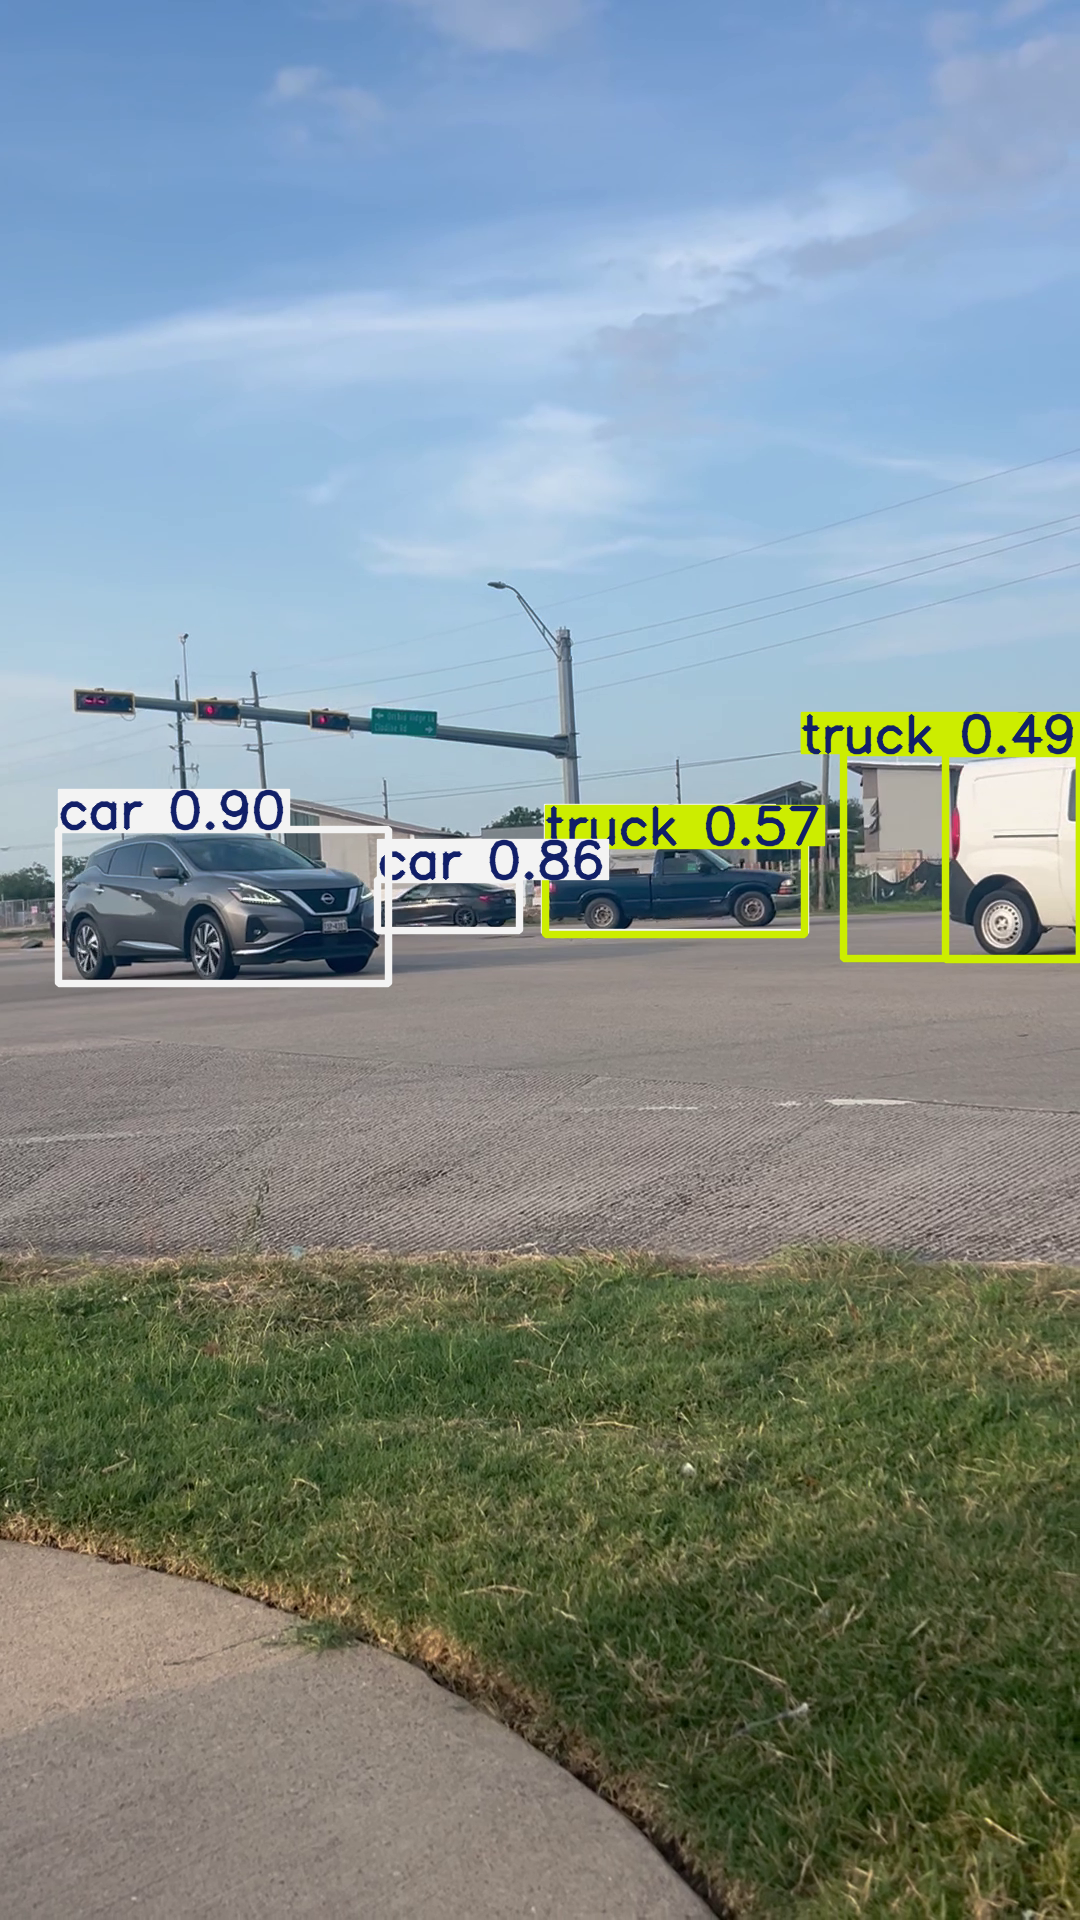

In [15]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2

video_path = "data/original_videos/IMG_8259.MOV"

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, 20000)
success, frame = cap.read()
cap.release()

print("Frame loaded:", success)
print("Frame shape:", frame.shape if success else None)

upright_frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

model = YOLO("yolo11n.pt")

result = model.predict(
    upright_frame,
    conf=0.05,
    imgsz=1280,
    classes=[2, 3, 5, 7],
    verbose=False
)[0]

print("Vehicles detected after rotation:", len(result.boxes))

for box in result.boxes:
    class_id = int(box.cls[0])
    print(result.names[class_id], round(float(box.conf[0]), 3))

cv2_imshow(result.plot())

**Create 10 scenarios and run the agents**

Every third frame is processed to reduce runtime while preserving tracking evidence.

In [16]:
!python tools/create_evaluation_set.py --source-folder data/original_videos --output-folder data/evaluation
!python agents/orchestrator.py --input data/evaluation --results results --frame-stride 3 --confidence 0.05
!python tools/summarize_evaluation.py --summary results/batch_summary.json --output results/metrics.txt

Created 10 scenarios in data/evaluation
[
  {
    "summary": {
      "input_file": "data/evaluation/blur.mp4",
      "status": "completed",
      "duration_seconds": 30.838473078846473,
      "frames_processed": 309,
      "inference_seconds": 10.884601769987057,
      "decision": {
        "traffic_level": "HIGH",
        "action": "Create congestion alert and recommend closer monitoring.",
        "reason": "The rule used peak visible vehicles=5 and line crossings per minute=38.9. Thresholds: HIGH at peak>=8 or flow>=12; MODERATE at peak>=4 or flow>=6; otherwise LOW.",
        "unique_vehicles": 54,
        "line_crossings": 20,
        "peak_visible": 5,
        "counts_by_class": {
          "bus": 1,
          "car": 50,
          "truck": 18
        }
      },
      "warnings": []
    },
    "files": {
      "trace": "results/traces/blur_trace.json",
      "report": "results/blur_report.txt",
      "frames": "results/traces/blur_frames.csv"
    },
    "annotated_video": "results/

In [10]:
from pathlib import Path
import shutil
import os

# 1. Make every video frame upright before detection
perception_file = Path("agents/perception_agent.py")
perception_code = perception_file.read_text()

old_line = "            frame = resize_for_inference(frame)"
new_lines = """            frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
            frame = resize_for_inference(frame)"""

if "cv2.ROTATE_90_CLOCKWISE" not in perception_code:
    perception_code = perception_code.replace(old_line, new_lines)

perception_file.write_text(perception_code)

# 2. Use YOLO11 and a larger inference size
detector_file = Path("tools/detector.py")
detector_code = detector_file.read_text()

detector_code = detector_code.replace(
    'model_name="yolov8n.pt"',
    'model_name="yolo11n.pt"'
)

detector_code = detector_code.replace(
    "            verbose=False,",
    "            imgsz=1280,\n            verbose=False,"
)

detector_file.write_text(detector_code)

# 3. Remove the incorrect zero-count results
if os.path.exists("results"):
    shutil.rmtree("results")

print("Rotation and detector corrections applied.")

Rotation and detector corrections applied.


## Review metrics and download results

In [14]:
from pathlib import Path
print(Path('results/metrics.txt').read_text())
!zip -qr smartflow_results.zip results
from google.colab import files
files.download('smartflow_results.zip')

SMARTFLOW EVALUATION RESULTS
Scenarios: 10
Completed: 10
Task success rate: 100.0%

scenario | vehicles | crossings | peak | level | sec/frame
blur.mp4 | 54 | 20 | 5 | HIGH | 0.0344
center_occlusion.mp4 | 14 | 6 | 6 | MODERATE | 0.0247
dark.mp4 | 47 | 20 | 6 | HIGH | 0.0263
grayscale.mp4 | 52 | 19 | 7 | HIGH | 0.0264
low_resolution.mp4 | 62 | 21 | 5 | HIGH | 0.0263
original_IMG_8256.mp4 | 33 | 12 | 11 | HIGH | 0.0264
original_IMG_8257.mp4 | 74 | 29 | 10 | HIGH | 0.0271
original_IMG_8258.mp4 | 18 | 5 | 5 | MODERATE | 0.0260
original_IMG_8259.mp4 | 50 | 20 | 6 | HIGH | 0.0267
short_clip.mp4 | 9 | 1 | 3 | LOW | 0.0256

FAILURE ANALYSIS TO COMPLETE AFTER VISUAL REVIEW:
1. Foreground/center occlusion: compare center_occlusion with original IMG_8259.
2. Image degradation: compare dark, blur, and low_resolution with original IMG_8259.
Explain which vehicles were missed, duplicated, or assigned new track IDs.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>